In [66]:
import cv2
import numpy as np
import os

# ===============================
# 🔥 여기만 바꿔가며 사용
# ===============================
LABEL_NAME = "Cancel"      # Circle / Triangle / Rectangle / Cancel
BASE_DIR = "dataset_96"
IMG_SIZE = 96              # ★ 96x96
AUG_PER_IMAGE = 12         # 한 번에 저장될 증강 수

SAVE_DIR = os.path.join(BASE_DIR, LABEL_NAME)
os.makedirs(SAVE_DIR, exist_ok=True)

# ===============================
# 카메라
# ===============================
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("웹캠을 열 수 없습니다.")
    exit()

print(f"[LABEL: {LABEL_NAME}] c : capture & augment | esc : exit")

img_count = len(os.listdir(SAVE_DIR))

# ===============================
# 컨투어 기반 crop 함수
# ===============================
def crop_by_contour(bin_img):
    cnts, _ = cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None

    c = max(cnts, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    if w * h < 500:  # 너무 작은 노이즈 제거
        return None

    pad = 10
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(bin_img.shape[1], x + w + pad)
    y2 = min(bin_img.shape[0], y + h + pad)

    crop = bin_img[y1:y2, x1:x2]

    # 정사각 패딩
    hh, ww = crop.shape
    size = max(hh, ww)
    out = np.zeros((size, size), dtype=np.uint8)
    oy = (size - hh) // 2
    ox = (size - ww) // 2
    out[oy:oy+hh, ox:ox+ww] = crop

    return out

# ===============================
# 도형 전용 증강
# ===============================
def augment_shape(img):
    aug = []
    h, w = img.shape
    k = np.ones((3, 3), np.uint8)

    # 회전
    for angle in [-15, -8, 8, 15]:
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
        aug.append(cv2.warpAffine(img, M, (w, h)))

    # 두께 변화
    aug.append(cv2.dilate(img, k, 1))
    aug.append(cv2.erode(img, k, 1))

    # 약한 블러
    aug.append(cv2.GaussianBlur(img, (3, 3), 0))

    return aug[:AUG_PER_IMAGE]

# ===============================
# 메인 루프
# ===============================
while True:
    ret, frame = cap.read()
    if not ret:
        break

    flip = cv2.flip(frame, 1)
    h, w, _ = flip.shape
    cx, cy = w // 2, h // 2

    roi = flip[cy-180:cy+180, cx-180:cx+180]
    cv2.rectangle(flip, (cx-180, cy-180), (cx+180, cy+180), (0,0,255), 2)
    cv2.imshow("Webcam", flip)

    key = cv2.waitKey(1) & 0xFF

    # ===============================
    # c : 촬영 + 증강 저장
    # ===============================
    if key == ord('c') or key == ord('C'):
        # 1) gray
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        gray = np.flip(gray, 1)

        # 2) blur
        blur = cv2.GaussianBlur(gray, (5, 5), 0)

        # 3) 이진화 (검은 배경 + 흰 도형)
        _, binary = cv2.threshold(
            blur, 0, 255,
            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
        )

        # 4) morph
        kernel = np.ones((3, 3), np.uint8)
        morph = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

        # 5) 컨투어 기준 crop
        cropped = crop_by_contour(morph)
        if cropped is None:
            print("SKIP: contour not found")
            continue

        # 6) 흰 픽셀 비율 필터
        white_ratio = (cropped > 0).mean()
        if not (0.03 <= white_ratio <= 0.6):
            print("SKIP: bad capture")
            continue

        # 7) resize to 96x96
        final_img = cv2.resize(
            cropped, (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )

        # -------------------------------
        # 저장 (원본)
        # -------------------------------
        cv2.imwrite(
            f"{SAVE_DIR}/img_{img_count:05d}.png",
            final_img
        )
        img_count += 1

        # -------------------------------
        # 증강 저장
        # -------------------------------
        for aug in augment_shape(final_img):
            cv2.imwrite(
                f"{SAVE_DIR}/img_{img_count:05d}.png",
                aug
            )
            img_count += 1

        print(f"[{LABEL_NAME}] saved {1 + AUG_PER_IMAGE} images")

        cv2.imshow("Saved sample (96x96)", final_img)

    if key == 27:
        break

cap.release()
cv2.destroyAllWindows()


[LABEL: Cancel] c : capture & augment | esc : exit
[Cancel] saved 13 images
[Cancel] saved 13 images
[Cancel] saved 13 images
[Cancel] saved 13 images
[Cancel] saved 13 images
[Cancel] saved 13 images
[Cancel] saved 13 images
[Cancel] saved 13 images
[Cancel] saved 13 images
[Cancel] saved 13 images
[Cancel] saved 13 images
[Cancel] saved 13 images
[Cancel] saved 13 images


In [68]:
import os
import glob
import cv2
import numpy as np

# ===============================
# 설정
# ===============================
BASE_DIR = ("dataset_96")  # dataset/Circle, dataset/Triangle ...
VALID_EXTS = (".png", ".jpg", ".jpeg", ".bmp")

# 폴더명을 라벨로 쓸 리스트 (원하는 순서로!)
CLASS_NAMES = ["Circle", "Triangle", "Rectangle", "Cancel"]

IMG_SIZE = (96, 96)

def load_dataset(base_dir: str, class_names: list[str]):
    X_list = []
    y_list = []

    for label_idx, class_name in enumerate(class_names):
        folder = os.path.join(base_dir, class_name)
        if not os.path.isdir(folder):
            print(f"[WARN] 폴더 없음: {folder} (건너뜀)")
            continue

        # 폴더 내 이미지 파일 전부 수집 (번호 구멍/삭제 상관 없음)
        files = []
        for ext in VALID_EXTS:
            files.extend(glob.glob(os.path.join(folder, f"*{ext}")))
        files = sorted(files)

        print(f"[INFO] {class_name}: {len(files)} files")

        for fp in files:
            img = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"[SKIP] 읽기 실패: {fp}")
                continue

            # 혹시 28x28이 아닐 수도 있으니 강제 리사이즈
            if img.shape[:2] != IMG_SIZE:
                img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)

            # 0~1 정규화 (선택)
            img = img.astype(np.float32) / 255.0

            # (28,28,1)로 채널 축 추가 (CNN용)
            img = np.expand_dims(img, axis=-1)

            X_list.append(img)
            y_list.append(label_idx)

    X = np.stack(X_list, axis=0) if X_list else np.empty((0, 28, 28, 1), dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)

    return X, y

# ===============================
# 실행
# ===============================
X, y = load_dataset(BASE_DIR, CLASS_NAMES)

print("X shape:", X.shape)   # (N, 28, 28, 1)
print("y shape:", y.shape)   # (N,)
print("classes:", CLASS_NAMES)
print("label counts:", {name: int(np.sum(y == i)) for i, name in enumerate(CLASS_NAMES)})


[INFO] Circle: 104 files
[INFO] Triangle: 192 files
[INFO] Rectangle: 112 files
[INFO] Cancel: 88 files
X shape: (496, 96, 96, 1)
y shape: (496,)
classes: ['Circle', 'Triangle', 'Rectangle', 'Cancel']
label counts: {'Circle': 104, 'Triangle': 192, 'Rectangle': 112, 'Cancel': 88}


In [69]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ===============================
# 0) 네가 이미 만든 배열이 있다고 가정:
# X, y
# 예: CLASS_NAMES = ["Circle","Triangle","Rectangle", "Cancel1"]
# ===============================

# ---- (필수) 형태/정규화 보정 ----
X = np.asarray(X)
y = np.asarray(y)

# 채널 축 없으면 추가
if X.ndim == 3:  # (N,28,28)
    X = X[..., np.newaxis]  # (N,28,28,1)

# 0~255면 0~1로 정규화
if X.max() > 1.0:
    X = X.astype("float32") / 255.0
else:
    X = X.astype("float32")

y = y.astype("int64")

num_classes = int(np.max(y)) + 1  # 또는 len(CLASS_NAMES)

# ===============================
# 1) train/val split
# ===============================
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("num_classes:", num_classes)

# ===============================
# 2) Keras Dataset (권장)
# ===============================
BATCH_SIZE = 64

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(min(len(X_train), 5000), seed=42, reshuffle_each_iteration=True) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

# ===============================
# 3) 모델 (가벼운 CNN)
# ===============================
model = keras.Sequential([
    layers.Input(shape=X.shape[1:]),  # (28,28,1)

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ===============================
# 4) 콜백(과적합 방지/자동 저장)
# ===============================
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        "shape_classifier.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )
]

# ===============================
# 5) 학습
# ===============================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

# ===============================
# 6) 평가 + 저장
# ===============================
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f"Final Val Acc: {val_acc:.4f}")

model.save("shape_classifier_final.keras")
print("Saved: shape_classifier.keras (best) / shape_classifier_final.keras (final)")


Train: (396, 96, 96, 1) (396,)
Val  : (100, 96, 96, 1) (100,)
num_classes: 4


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 96, 96, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,084 (367.52 KB)

 Trainable params: 93,636 (365.77 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 279ms/step - accuracy: 0.3939 - loss: 1.2260 - val_accuracy: 0.5300 - val_loss: 1.3338 - learning_rate: 0.0010
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step - accuracy: 0.5909 - loss: 0.9980 - val_accuracy: 0.5200 - val_loss: 1.2845 - learning_rate: 0.0010
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 245ms/step - accuracy: 0.6212 - loss: 0.9203 - val_accuracy: 0.5100 - val_loss: 1.2627 - learning_rate: 0.0010
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 246ms/step - accuracy: 0.6212 - loss: 0.8959 - val_accuracy: 0.4700 - val_loss: 1.2572 - learning_rate: 0.0010
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 278ms/step - accuracy: 0.6843 - loss: 0.8473 - val_accuracy: 0.4500 - val_loss: 1.2813 - learning_rate: 0.0010
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step - accuracy: 0.7020 - loss: 0.8226 - val_accuracy: 0.4000 - val_loss: 1.3286 - learning_rate: 0.0010
Final Val Acc: 0.5300
Saved: shape_classifier.keras (best) / shape_classifier_final.keras (final)


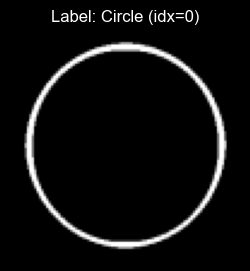

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# 가정:
# X.shape == (N, 28, 28, 1) 또는 (N, 28, 28)
# y.shape == (N,)
# CLASS_NAMES = ["Circle", "Triangle", "Rectangle", "Cancel"]

# -------------------------------
# 랜덤 인덱스
# -------------------------------
randIdx = np.random.randint(0, len(X))

# -------------------------------
# 이미지 & 라벨
# -------------------------------
img = X[randIdx]
label_idx = y[randIdx]
label_name = CLASS_NAMES[label_idx]

# 채널 축 제거 (imshow용)
if img.ndim == 3 and img.shape[-1] == 1:
    img = img.squeeze(-1)

# -------------------------------
# 출력
# -------------------------------
plt.figure(figsize=(3, 3))
plt.imshow(img, cmap="gray")
plt.title(f"Label: {label_name} (idx={label_idx})")
plt.axis("off")
plt.show()


In [ ]:
import cv2
import numpy as np
from tensorflow import keras

# ===============================
# 설정 (여기만 확인)
# ===============================
MODEL_PATH = "shape_classifier.keras"  # 네가 저장한 모델 파일명으로
CLASS_NAMES = ["Circle", "Triangle", "Rectangle", "Cancel"]  # 학습 때 라벨 순서 그대로!
IMG_SIZE = 96

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("웹캠을 열 수 없습니다.")
    exit()

model = keras.models.load_model(MODEL_PATH)
print("c : capture & predict | esc : exit")

# ===============================
# 컨투어 기반 crop + 정사각 패딩 (저장 코드와 동일)
# ===============================
def crop_by_contour(bin_img):
    cnts, _ = cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None

    c = max(cnts, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    if w * h < 500:  # 너무 작은 노이즈 제거
        return None

    pad = 10
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(bin_img.shape[1], x + w + pad)
    y2 = min(bin_img.shape[0], y + h + pad)

    crop = bin_img[y1:y2, x1:x2]

    # 정사각 패딩
    hh, ww = crop.shape
    size = max(hh, ww)
    out = np.zeros((size, size), dtype=np.uint8)
    oy = (size - hh) // 2
    ox = (size - ww) // 2
    out[oy:oy+hh, ox:ox+ww] = crop
    return out

# ===============================
# 메인 루프
# ===============================
while True:
    ret, frame = cap.read()
    if not ret:
        print("프레임을 가져 올 수 없습니다.")
        break

    flip = cv2.flip(frame, 1)
    h, w, _ = flip.shape
    cx, cy = w // 2, h // 2

    # ROI를 저장 코드와 동일하게 (360x360)
    roi = flip[cy-180:cy+180, cx-180:cx+180]
    cv2.rectangle(flip, (cx-180, cy-180), (cx+180, cy+180), (0, 0, 255), 2)

    cv2.imshow("Webcam", flip)

    key = cv2.waitKey(1) & 0xFF

    if key == ord('c') or key == ord('C'):
        # 1) grayscale
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        gray = np.flip(gray, 1)

        # 2) blur
        blur = cv2.GaussianBlur(gray, (5, 5), 0)

        # 3) 이진화 (검은 배경 + 흰 도형)
        _, binary = cv2.threshold(
            blur, 0, 255,
            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
        )

        # 4) morph (노이즈 제거)
        kernel = np.ones((3, 3), np.uint8)
        morph = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

        # 5) 컨투어 기준 crop + 정사각 패딩
        cropped = crop_by_contour(morph)
        if cropped is None:
            print("SKIP: contour not found")
            continue

        # 6) 흰 픽셀 비율 필터
        white_ratio = (cropped > 0).mean()
        if not (0.03 <= white_ratio <= 0.6):
            print("SKIP: bad capture (white_ratio={:.3f})".format(white_ratio))
            continue

        # 7) 96x96 리사이즈
        img96 = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

        # 8) 모델 입력 형태로 (1,96,96,1) + 정규화
        x = img96.astype(np.float32) / 255.0
        x = x[np.newaxis, :, :, np.newaxis]

        # 예측
        prob = model.predict(x, verbose=0)[0]
        idx = int(np.argmax(prob))
        conf = float(prob[idx])
        name = CLASS_NAMES[idx] if idx < len(CLASS_NAMES) else str(idx)

        print(f"Predicted: {name} (idx={idx}, conf={conf:.3f})")

        # 확인용
        cv2.imshow("Processed (96x96 input)", img96)

    if key == 27:
        break

cap.release()
cv2.destroyAllWindows()


c : capture & predict | esc : exit
Predicted: Triangle (idx=1, conf=0.269)
Predicted: Triangle (idx=1, conf=0.267)
Predicted: Triangle (idx=1, conf=0.271)
Predicted: Triangle (idx=1, conf=0.275)
Predicted: Triangle (idx=1, conf=0.275)
Predicted: Triangle (idx=1, conf=0.275)
Predicted: Triangle (idx=1, conf=0.275)
Predicted: Triangle (idx=1, conf=0.274)
Predicted: Circle (idx=0, conf=0.310)
Predicted: Circle (idx=0, conf=0.303)
Predicted: Circle (idx=0, conf=0.336)
Predicted: Circle (idx=0, conf=0.323)
Predicted: Circle (idx=0, conf=0.295)
Predicted: Triangle (idx=1, conf=0.274)
Predicted: Circle (idx=0, conf=0.299)
Predicted: Circle (idx=0, conf=0.296)
Predicted: Triangle (idx=1, conf=0.269)
Predicted: Circle (idx=0, conf=0.329)
Predicted: Circle (idx=0, conf=0.334)
Predicted: Circle (idx=0, conf=0.315)
Predicted: Triangle (idx=1, conf=0.271)
Predicted: Triangle (idx=1, conf=0.275)
Predicted: Triangle (idx=1, conf=0.274)
Predicted: Triangle (idx=1, conf=0.271)
Predicted: Triangle (idx=

In [ ]:
load_model = keras.models.load_model("my_first_DNN_model.keras")